# ======== import libraries ============

-  kidney stone detection from the segmented datasets

# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import cv2
from sklearn.utils.multiclass import unique_labels
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras import Sequential
from keras.models import load_model
from keras.applications.vgg16 import VGG16 # For Transfer Learning
from keras.applications.inception_v3 import InceptionV3
from keras.applications.resnet50 import ResNet50
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import SGD,Adam
from keras.callbacks import ReduceLROnPlateau
from keras.layers import Flatten,Dense,BatchNormalization,Activation,Dropout
from keras.utils import to_categorical
from keras.models import Sequential,Model
import matplotlib.pyplot as plt
# import tensorflow_addons as tfa
from keras import layers
import pickle
from tensorflow import keras
import tensorflow as tf
from sklearn.metrics import accuracy_score
import joblib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import pickle


# ====== Dataset preprocessing ===========

In [2]:
import os
os.path.exists('dataset1(aug)')

True

## Test dataset

In [6]:
print('Train datasets:\n')
print('normal: ',len(os.listdir('dataset1(aug)/test/Normal')))
print('cyst: ',len(os.listdir('dataset1(aug)/test/Cyst')))
print('tumor: ',len(os.listdir('dataset1(aug)/test/Tumor')))
print('stone: ',len(os.listdir('dataset1(aug)/test/Stone')))

Train datasets:

normal:  312
cyst:  312
tumor:  312
stone:  312


## Visualization of test dataset

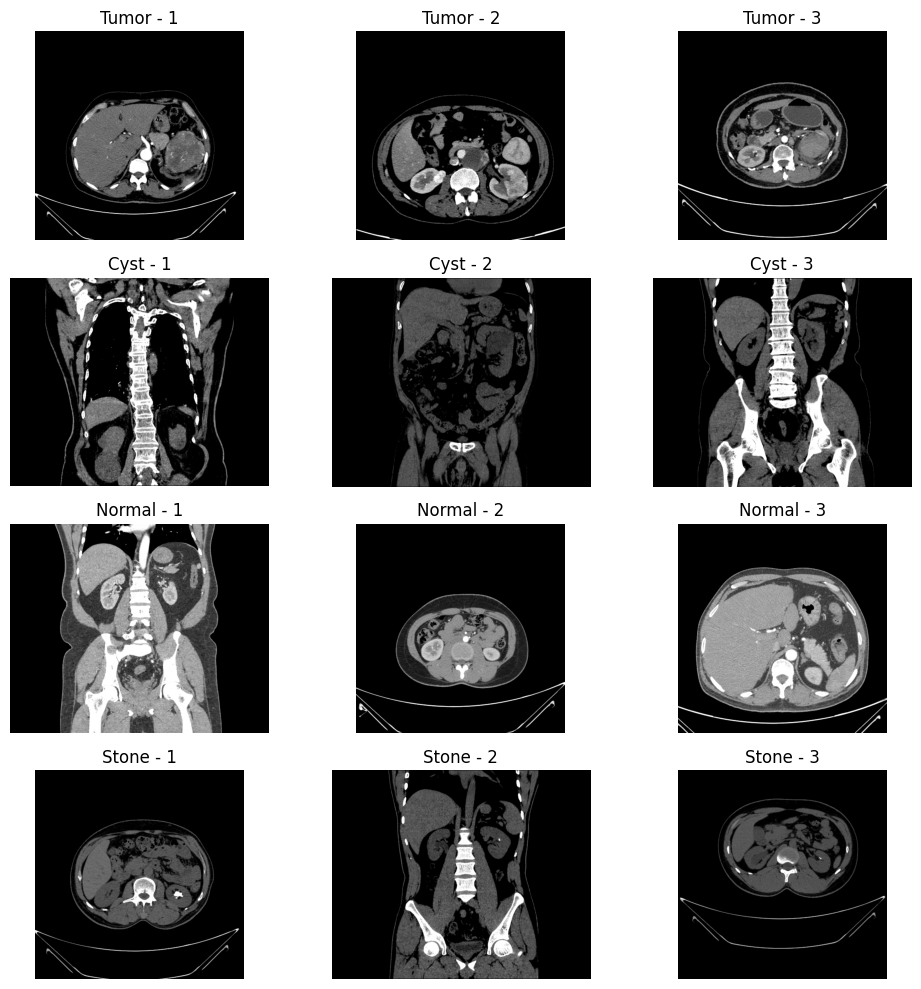

In [36]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Define the path to the test dataset
test_dataset_path = 'dataset1(aug)/train'

# Define the classes
classes = ['Tumor', 'Cyst', 'Normal', 'Stone']

# Set the number of images to visualize for each class
num_images_per_class = 3

# Create a subplot for visualization
fig, axs = plt.subplots(len(classes), num_images_per_class, figsize=(10, 10))

# Loop through each class
for i, class_name in enumerate(classes):
    class_path = os.path.join(test_dataset_path, class_name)

    # Get a list of image files in the class folder
    image_files = os.listdir(class_path)

    # Randomly select images
    selected_images = random.sample(image_files, num_images_per_class)

    # Loop through each selected image in the class
    for j, image_file in enumerate(selected_images):
        image_path = os.path.join(class_path, image_file)

        # Load and display the image
        img = Image.open(image_path)
        axs[i, j].imshow(img)
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{class_name} - {j+1}')

# Adjust layout for better visualization
# plt.title('Samples of datasets')
plt.tight_layout()
plt.show()


# =========== Train Models ==============

### Accuracy and loss function

In [9]:
import matplotlib.pyplot as plt

def accuracy_plot(df):
    accuracy_train = df['accuracy']
    accuracy_val = df['val_accuracy']
    epochs = range(1, len(accuracy_train) + 1)
    plt.plot(epochs, accuracy_train, 'g', label='Training accuracy')
    plt.plot(epochs, accuracy_val, 'b', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

def loss_plot(df):
    loss_train = df['loss']
    loss_val = df['val_loss']
    epochs = range(1, len(loss_train) + 1)
    plt.plot(epochs, loss_train, 'g', label='Training Loss')
    plt.plot(epochs, loss_val, 'b', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

## 1 VGG 16

In [9]:
from keras.models import Model
vgg_base_model = VGG16(weights = 'imagenet', include_top = False, input_shape = (224,224,3))
for layer in vgg_base_model.layers:
    layer.trainable = False
vgg_top_model =Flatten()(vgg_base_model.output)

vgg_top_model = Dense(512,activation='relu')(vgg_top_model)
vgg_top_model = Dropout(0.10)(vgg_top_model)
vgg_top_model = Dense(256,activation='relu')(vgg_top_model)
vgg_top_model = Dropout(0.05)(vgg_top_model)
vgg_top_model = Dense(128,activation='relu')(vgg_top_model)
vgg_top_model = Dropout(0.05)(vgg_top_model)

vgg_top_model = Dense(4,activation='softmax')(vgg_top_model)
vgg_model = Model(inputs = vgg_base_model.input, outputs = vgg_top_model)

vgg_model.compile(optimizer=Adam(), loss = 'categorical_crossentropy',metrics = ['accuracy'])
history = vgg_model.fit(
    train_generator,
    steps_per_epoch = len(train_generator),
    epochs = 30,
    validation_data = val_generator)

# save model 
VGG16_Filename = "model_4classes/vgg_16_model.pkl"
with open(VGG16_Filename, 'wb') as file:
    pickle.dump(vgg_model, file)

# save losses as csv for losses plot
df=pd.DataFrame(history.history,index=None)
df. to_csv('losses_csv/vgg16(4).csv')

2024-05-21 18:11:48.205927: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/30


2024-05-21 18:11:55.036598: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 822083584 exceeds 10% of free system memory.
2024-05-21 18:11:55.609451: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 822083584 exceeds 10% of free system memory.


  1/279 [..............................] - ETA: 37:21 - loss: 1.3958 - accuracy: 0.3594

2024-05-21 18:12:00.005582: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 822083584 exceeds 10% of free system memory.
2024-05-21 18:12:00.109414: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 822083584 exceeds 10% of free system memory.


  2/279 [..............................] - ETA: 19:37 - loss: 2.7922 - accuracy: 0.3359

2024-05-21 18:12:04.254925: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 822083584 exceeds 10% of free system memory.


279/279 [==============================] - 1400s 5s/step - loss: 0.9671 - accuracy: 0.6094 - val_loss: 0.4682 - val_accuracy: 0.8189
Epoch 2/30
279/279 [==============================] - 1400s 5s/step - loss: 0.4299 - accuracy: 0.8340 - val_loss: 0.4030 - val_accuracy: 0.8518
Epoch 3/30
279/279 [==============================] - 1401s 5s/step - loss: 0.3279 - accuracy: 0.8731 - val_loss: 0.2275 - val_accuracy: 0.9263
Epoch 4/30
279/279 [==============================] - 1402s 5s/step - loss: 0.2632 - accuracy: 0.9003 - val_loss: 0.2030 - val_accuracy: 0.9255
Epoch 5/30
279/279 [==============================] - 1402s 5s/step - loss: 0.2311 - accuracy: 0.9139 - val_loss: 0.3007 - val_accuracy: 0.8958
Epoch 6/30
279/279 [==============================] - 1402s 5s/step - loss: 0.2002 - accuracy: 0.9268 - val_loss: 0.2170 - val_accuracy: 0.9167
Epoch 7/30
279/279 [==============================] - 1404s 5s/step - loss: 0.1982 - accuracy: 0.9274 - val_loss: 0.1392 - val_accuracy: 0.9463
Epo

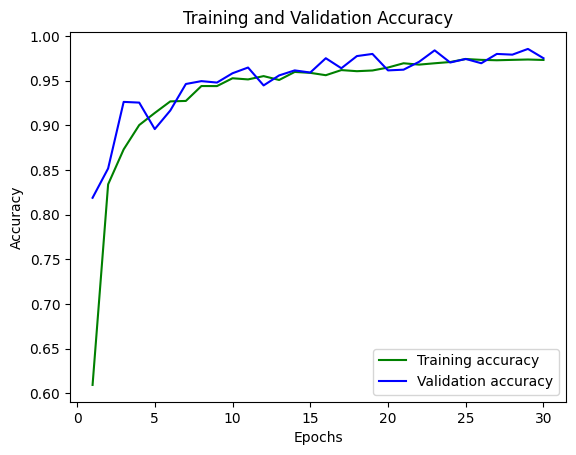

In [10]:
accuracy_plot(history.history)

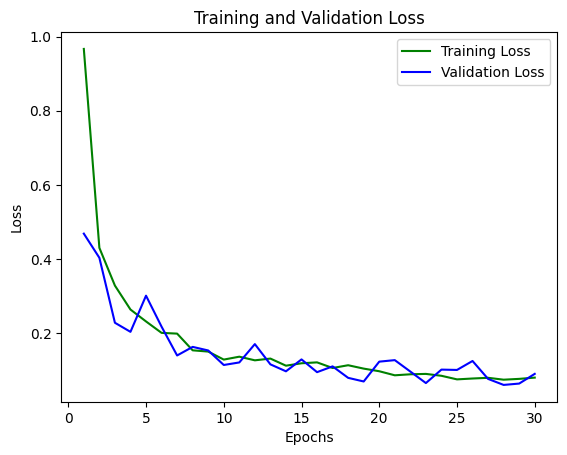

In [11]:
loss_plot(history.history)

## 2 ResNet152V2

In [9]:
from keras.models import Sequential, Model
from keras.layers import Flatten, Dense, Dropout
import tensorflow as tf

base_model = tf.keras.applications.ResNet152V2(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

top_model = Flatten()(base_model.output)

top_model = Dense(512, activation='relu')(top_model)
top_model = Dropout(0.10)(top_model)
top_model = Dense(256, activation='relu')(top_model)
top_model = Dropout(0.05)(top_model)
top_model = Dense(128, activation='relu')(top_model)
top_model = Dropout(0.05)(top_model)

top_model = Dense(4, activation='softmax')(top_model)

resnet_model = Model(inputs=base_model.input, outputs=top_model)

# optimizer = tf.keras.optimizers.Adam(lr=0.05)
resnet_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history = resnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=val_generator)


#save model 
resnet152v2_Filename = "model_4classes/resnet152v2_model.pkl"
with open(resnet152v2_Filename, 'wb') as file:
    pickle.dump(resnet_model, file)

# save losses as csv for losses plot
df=pd.DataFrame(history.history,index=None)
df. to_csv('losses_csv/resnet152v2(4).csv')

2024-05-22 23:52:31.938041: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/30
279/279 [==============================] - 1656s 6s/step - loss: 1.7615 - accuracy: 0.6625 - val_loss: 0.4084 - val_accuracy: 0.8397
Epoch 2/30
279/279 [==============================] - 1646s 6s/step - loss: 0.4247 - accuracy: 0.8431 - val_loss: 0.3325 - val_accuracy: 0.8830
Epoch 3/30
279/279 [==============================] - 1645s 6s/step - loss: 0.3190 - accuracy: 0.8826 - val_loss: 0.2245 - val_accuracy: 0.9079
Epoch 4/30
279/279 [==============================] - 1644s 6s/step - loss: 0.2513 - accuracy: 0.9091 - val_loss: 0.2096 - val_accuracy: 0.9175
Epoch 5/30
279/279 [==============================] - 1642s 6s/step - loss: 0.2125 - accuracy: 0.9226 - val_loss: 0.1799 - val_accuracy: 0.9311
Epoch 6/30
279/279 [==============================] - 1643s 6s/step - loss: 0.1836 - accuracy: 0.9338 - val_loss: 0.2262 - val_accuracy: 0.9247
Epoch 7/30
279/279 [==============================] - 1642s 6s/step - loss: 0.1696 - accuracy: 0.9416 - val_loss: 0.1210 - val_accuracy:

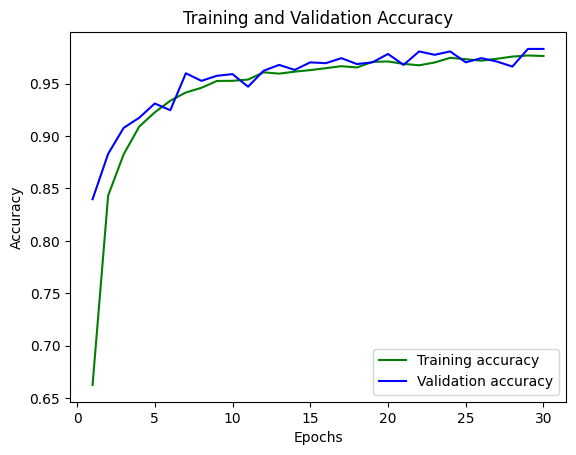

In [11]:
accuracy_plot(history.history)

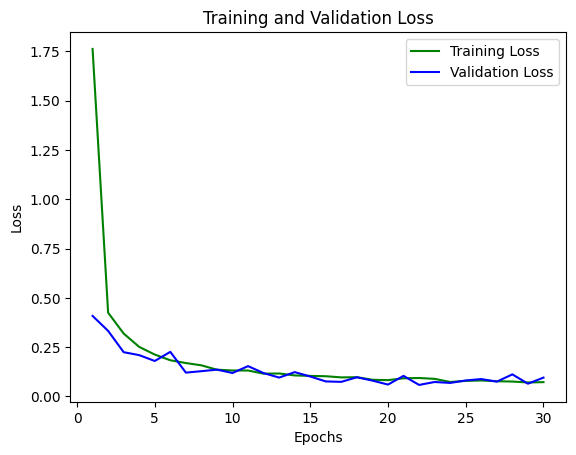

In [12]:
loss_plot(history.history)

## 3 InceptionResNet-V2

In [9]:
from keras.applications import InceptionResNetV2
from keras.models import Sequential, Model
from keras.layers import Flatten, Dense, Dropout
import tensorflow as tf

base_model = InceptionResNetV2(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

top_model = Flatten()(base_model.output)

top_model = Dense(512, activation='relu')(top_model)
top_model = Dropout(0.10)(top_model)
top_model = Dense(256, activation='relu')(top_model)
top_model = Dropout(0.05)(top_model)
top_model = Dense(128, activation='relu')(top_model)
top_model = Dropout(0.05)(top_model)

top_model = Dense(4, activation='softmax')(top_model)

InceptResnet = Model(inputs=base_model.input, outputs=top_model)

# optimizer = tf.keras.optimizers.Adam(lr=0.05)
InceptResnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history = InceptResnet.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=val_generator)

#save model 
InceptResnet_Filename = "model_4classes/incept_resnetv2_model.pkl"
with open(InceptResnet_Filename, 'wb') as file:
    pickle.dump(InceptResnet, file)

# save losses as csv for losses plot
df=pd.DataFrame(history.history,index=None)
df. to_csv('losses_csv/incept_resnetv2(4).csv')

2024-05-23 23:42:14.952164: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/30
  2/279 [..............................] - ETA: 12:42 - loss: 11.8013 - accuracy: 0.2969

279/279 [==============================] - 884s 3s/step - loss: 1.7511 - accuracy: 0.5982 - val_loss: 0.6464 - val_accuracy: 0.7372
Epoch 2/30
279/279 [==============================] - 878s 3s/step - loss: 0.5642 - accuracy: 0.7817 - val_loss: 0.4116 - val_accuracy: 0.8405
Epoch 3/30
279/279 [==============================] - 878s 3s/step - loss: 0.4351 - accuracy: 0.8354 - val_loss: 0.3820 - val_accuracy: 0.8438
Epoch 4/30
279/279 [==============================] - 881s 3s/step - loss: 0.4028 - accuracy: 0.8441 - val_loss: 0.3242 - val_accuracy: 0.8798
Epoch 5/30
279/279 [==============================] - 882s 3s/step - loss: 0.3485 - accuracy: 0.8716 - val_loss: 0.2506 - val_accuracy: 0.9062
Epoch 6/30
279/279 [==============================] - 880s 3s/step - loss: 0.3038 - accuracy: 0.8866 - val_loss: 0.2580 - val_accuracy: 0.9071
Epoch 7/30
279/279 [==============================] - 880s 3s/step - loss: 0.2865 - accuracy: 0.8938 - val_loss: 0.2351 - val_accuracy: 0.9199
Epoch 8/30

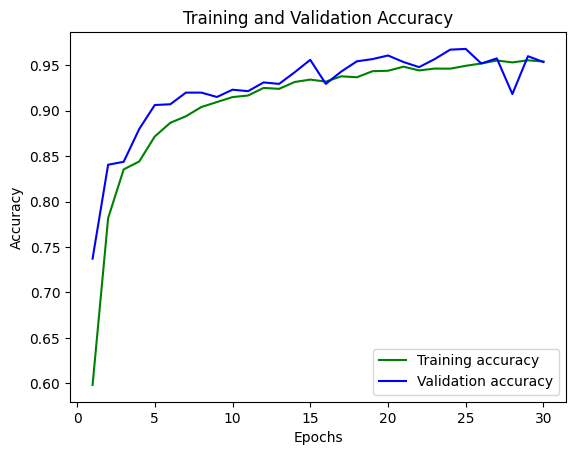

In [11]:
accuracy_plot(history.history)

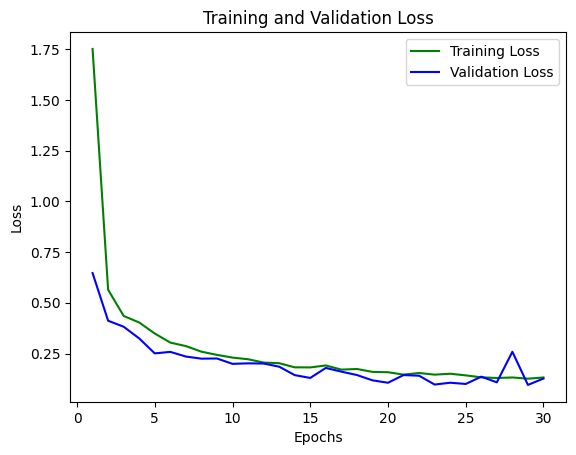

In [12]:
loss_plot(history.history)

## 4 DenseNet201

In [38]:
from keras.applications import DenseNet201
from keras.models import Sequential, Model
from keras.layers import Flatten, Dense, Dropout
import tensorflow as tf

base_model = DenseNet201(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

top_model = Flatten()(base_model.output)

top_model = Dense(512, activation='relu')(top_model)
top_model = Dropout(0.10)(top_model)
top_model = Dense(256, activation='relu')(top_model)
top_model = Dropout(0.05)(top_model)
top_model = Dense(128, activation='relu')(top_model)
top_model = Dropout(0.05)(top_model)

top_model = Dense(4, activation='softmax')(top_model)

densenet_model = Model(inputs=base_model.input, outputs=top_model)

# optimizer = tf.keras.optimizers.Adam(lr=0.05)
densenet_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history = densenet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=val_generator)

#save model 
densenet_Filename = "model_4classes/densenet201_model.pkl"
with open(densenet_Filename, 'wb') as file:
    pickle.dump(densenet_model, file)

# save losses as csv for losses plot
df=pd.DataFrame(history.history,index=None)
df. to_csv('losses_csv/densenet201(4).csv')

Epoch 1/30
279/279 [==============================] - 1333s 5s/step - loss: 1.6784 - accuracy: 0.6762 - val_loss: 0.3418 - val_accuracy: 0.8646
Epoch 2/30
279/279 [==============================] - 1291s 5s/step - loss: 0.3809 - accuracy: 0.8548 - val_loss: 0.2143 - val_accuracy: 0.9207
Epoch 3/30
279/279 [==============================] - 1293s 5s/step - loss: 0.2603 - accuracy: 0.9019 - val_loss: 0.1610 - val_accuracy: 0.9423
Epoch 4/30
279/279 [==============================] - 1291s 5s/step - loss: 0.2293 - accuracy: 0.9166 - val_loss: 0.1629 - val_accuracy: 0.9423
Epoch 5/30
279/279 [==============================] - 1290s 5s/step - loss: 0.1646 - accuracy: 0.9408 - val_loss: 0.1570 - val_accuracy: 0.9391
Epoch 6/30
279/279 [==============================] - 1293s 5s/step - loss: 0.1495 - accuracy: 0.9443 - val_loss: 0.1177 - val_accuracy: 0.9583
Epoch 7/30
279/279 [==============================] - 1294s 5s/step - loss: 0.1238 - accuracy: 0.9552 - val_loss: 0.1444 - val_accuracy:

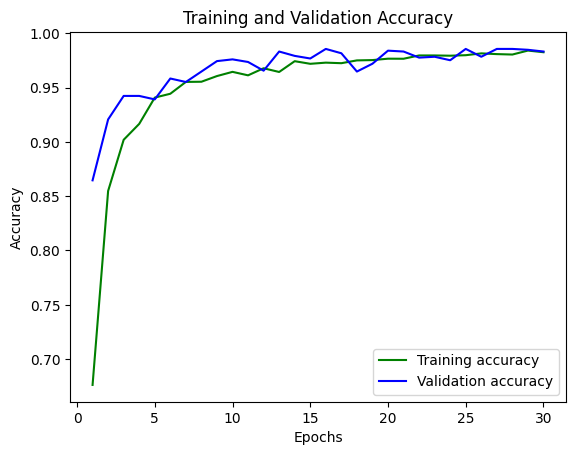

In [40]:
accuracy_plot(history.history)

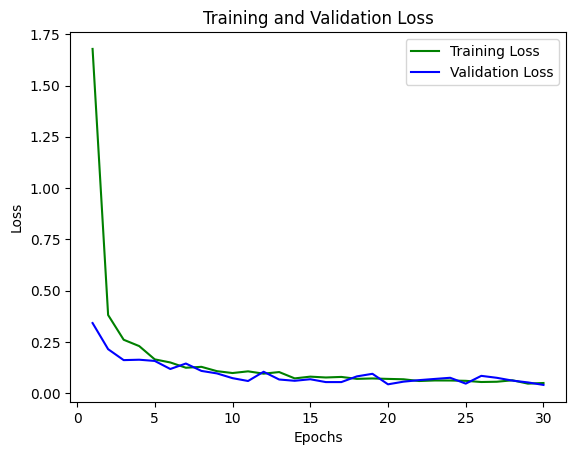

In [41]:
loss_plot(history.history)

# ========== Test Models ==============

In [4]:
from keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create an ImageDataGenerator for your test dataset
test_datagen = ImageDataGenerator(rescale=1.0/255.0)  # You can add more preprocessing options if needed
# Load your test dataset using the ImageDataGenerator
test_generator = test_datagen.flow_from_directory(
    'dataset1(aug)/test',  # Path to your test data
    target_size=(224, 224),  # Replace with your image dimensions
    batch_size=64,
    class_mode='categorical',  # If you are using categorical labels
    shuffle=False  # Set to False to maintain the order of samples
)

# Verify the number of classes in the test generator
num_classes = len(test_generator.class_indices)
print("Number of classes in test generator:", num_classes)

Found 1248 images belonging to 4 classes.
Number of classes in test generator: 4


## Visualize some test data

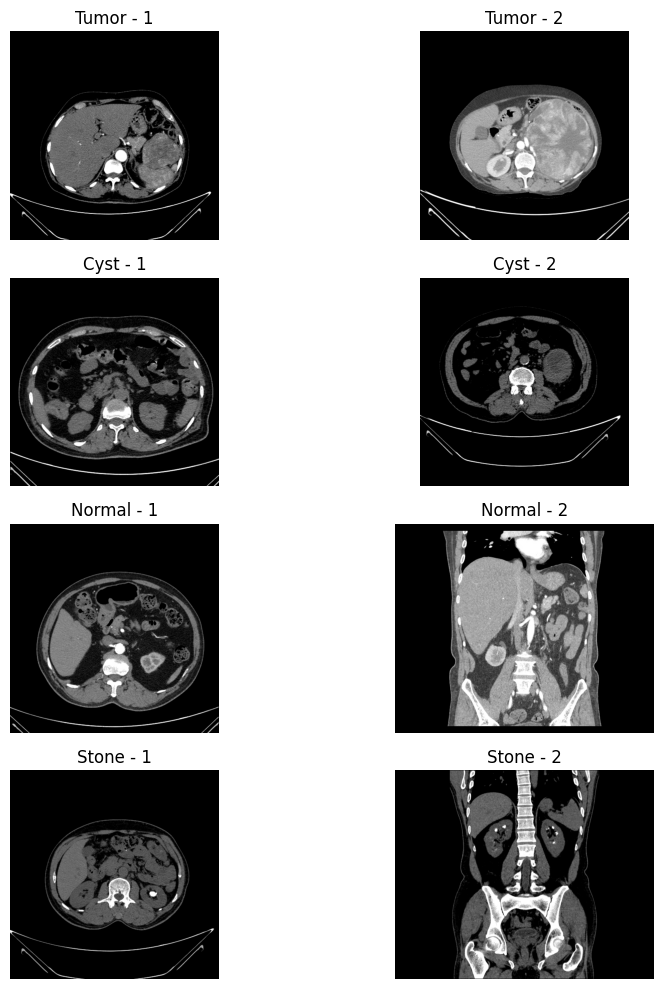

In [44]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the path to the test dataset
test_dataset_path = 'dataset1(aug)/test'

# Define the classes
classes = ['Tumor', 'Cyst', 'Normal', 'Stone']

# Set the number of images to visualize for each class
num_images_per_class = 2

# Create a subplot for visualization
fig, axs = plt.subplots(len(classes), num_images_per_class, figsize=(10, 10))

# Loop through each class
for i, class_name in enumerate(classes):
    class_path = os.path.join(test_dataset_path, class_name)

    # Get a list of image files in the class folder
    image_files = os.listdir(class_path)[:num_images_per_class]

    # Loop through each image in the class
    for j, image_file in enumerate(image_files):
        image_path = os.path.join(class_path, image_file)

        # Load and display the image
        img = Image.open(image_path)
        axs[i, j].imshow(img)
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{class_name} - {j+1}')

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

## 4 densenet201

20/20 [==============================] - 141s 7s/step
              precision    recall  f1-score   support

        Cyst       0.97      1.00      0.98       312
      Normal       1.00      0.96      0.98       312
       Stone       0.96      0.97      0.97       312
       Tumor       1.00      0.99      1.00       312

    accuracy                           0.98      1248
   macro avg       0.98      0.98      0.98      1248
weighted avg       0.98      0.98      0.98      1248



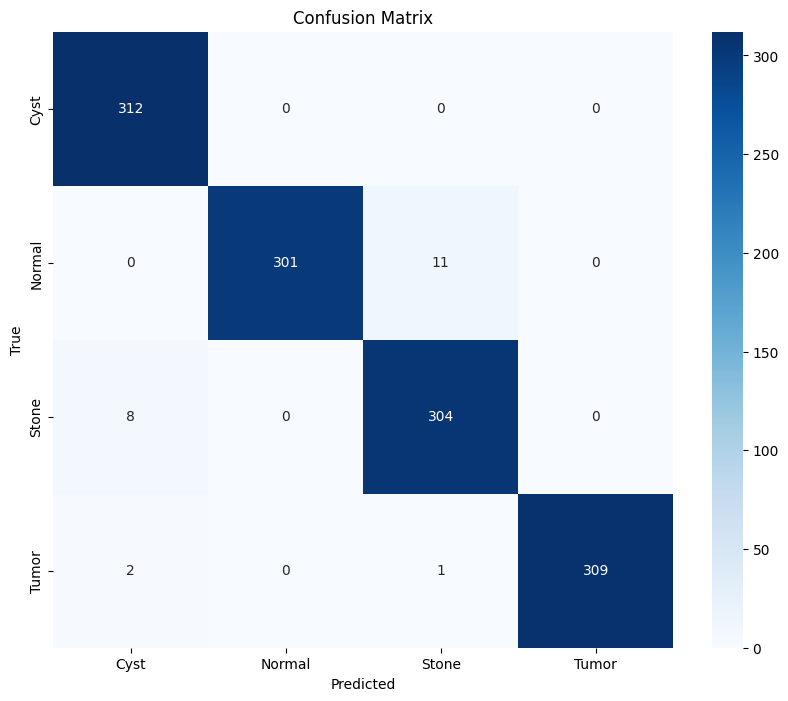

In [45]:
# Load your model using Pickle
with open("model_4classes/densenet201_model.pkl", "rb") as file:
    densenet_model = pickle.load(file)
# Use the model to make predictions on the test dataset
predictions = densenet_model.predict(test_generator, steps=len(test_generator), verbose=1)
# Get the true labels from the test generator
true_labels = test_generator.classes
# Calculate predicted labels from the probability scores
predicted_labels = np.argmax(predictions, axis=1)
# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=test_generator.class_indices)
# Print the classification report
print(report)

# Create a confusion matrix
confusion_mat = confusion_matrix(true_labels, predicted_labels)
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [46]:
# Calculate accuracy
accuracy_stacking = accuracy_score(true_labels, predicted_labels)
print("Densenet201 Accuracy :", accuracy_stacking)

Densenet201 Accuracy : 0.9823717948717948


## 3 InceptionResNet-V2

20/20 [==============================] - 103s 3s/step
              precision    recall  f1-score   support

        Cyst       0.99      0.99      0.99       312
      Normal       0.99      0.97      0.98       312
       Stone       0.97      0.98      0.98       312
       Tumor       0.98      0.99      0.98       312

    accuracy                           0.98      1248
   macro avg       0.98      0.98      0.98      1248
weighted avg       0.98      0.98      0.98      1248



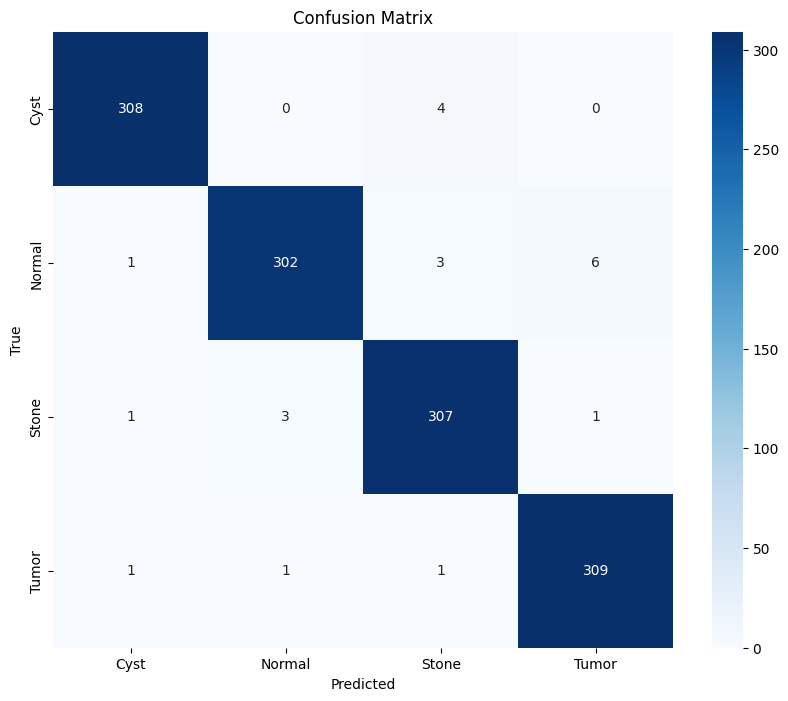

In [53]:
# Load your model using Pickle
with open("model_4classes/incept_resnetv2_model.pkl", "rb") as file:
    InceptResnet = pickle.load(file)

# Use the model to make predictions on the test dataset
predictions = InceptResnet.predict(test_generator, steps=len(test_generator), verbose=1)
# Get the true labels from the test generator
true_labels = test_generator.classes
# Calculate predicted labels from the probability scores
predicted_labels = np.argmax(predictions, axis=1)
# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=test_generator.class_indices)
# Print the classification report
print(report)

# Create a confusion matrix
confusion_mat = confusion_matrix(true_labels, predicted_labels)
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [54]:
# Calculate accuracy
accuracy_stacking = accuracy_score(true_labels, predicted_labels)
print("InceptionResnetV2 Accuracy :", accuracy_stacking)

InceptionResnetV2 Accuracy : 0.9823717948717948


## 2 ResNet152V2

20/20 [==============================] - 116s 6s/step
              precision    recall  f1-score   support

        Cyst       0.99      0.99      0.99       312
      Normal       0.99      0.98      0.99       312
       Stone       0.98      0.99      0.99       312
       Tumor       0.99      0.99      0.99       312

    accuracy                           0.99      1248
   macro avg       0.99      0.99      0.99      1248
weighted avg       0.99      0.99      0.99      1248



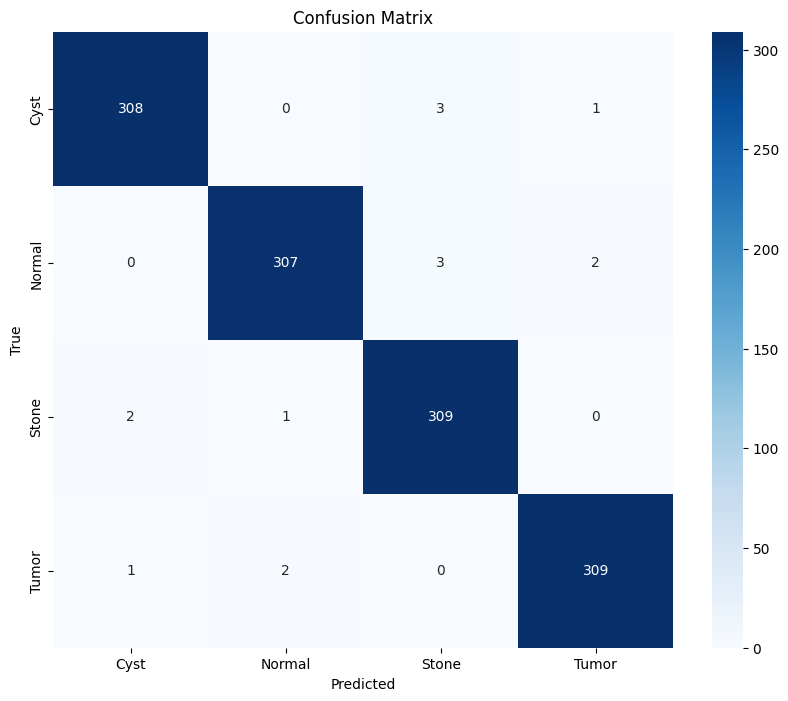

In [47]:
# # Load your model using Pickle
with open("model_4classes/resnet152v2_model.pkl", "rb") as file:
    resnet_model = pickle.load(file)

# Use the model to make predictions on the test dataset
predictions = resnet_model.predict(test_generator, steps=len(test_generator), verbose=1)
# Get the true labels from the test generator
true_labels = test_generator.classes
# Calculate predicted labels from the probability scores
predicted_labels = np.argmax(predictions, axis=1)
# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=test_generator.class_indices)
# Print the classification report
print(report)

# Create a confusion matrix
confusion_mat = confusion_matrix(true_labels, predicted_labels)
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [2]:
# 15/1248 * 100 -100

In [48]:
# Calculate accuracy
accuracy_stacking = accuracy_score(true_labels, predicted_labels)
print("Densenet201 Accuracy :", accuracy_stacking)

Densenet201 Accuracy : 0.9879807692307693


## 1 Vgg16

In [49]:
from sklearn.metrics import confusion_matrix,classification_report
# Load your model using Pickle
with open("model_4classes/vgg_16_model.pkl", "rb") as file:
    vgg16_model = pickle.load(file)

In [ ]:
vgg16_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

20/20 [==============================] - 114s 6s/step
              precision    recall  f1-score   support

        Cyst       0.95      1.00      0.97       312
      Normal       0.98      1.00      0.99       312
       Stone       1.00      0.95      0.97       312
       Tumor       1.00      0.97      0.99       312

    accuracy                           0.98      1248
   macro avg       0.98      0.98      0.98      1248
weighted avg       0.98      0.98      0.98      1248



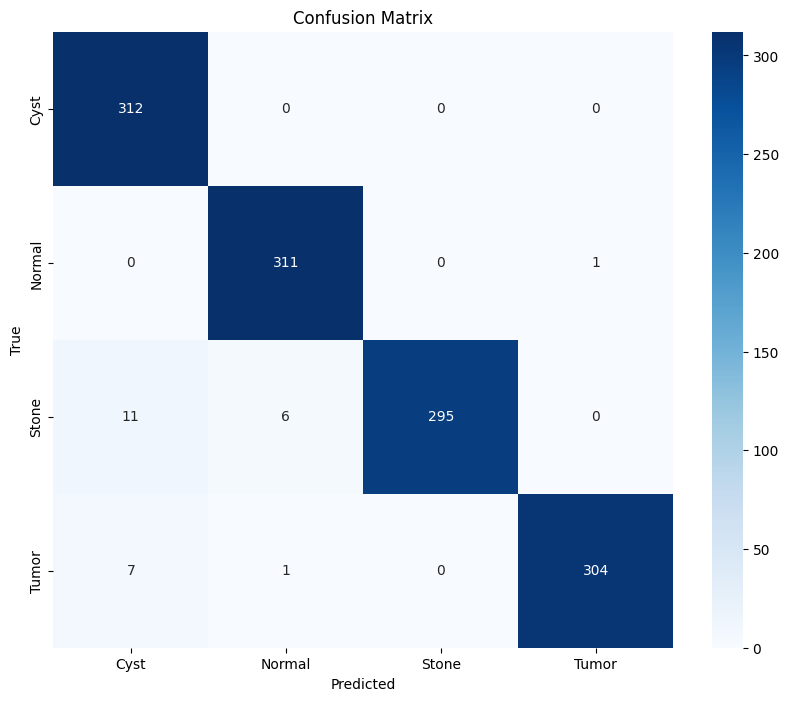

In [ ]:
# Use the model to make predictions on the test dataset
predictions = vgg16_model.predict(test_generator, steps=len(test_generator), verbose=1)
# Get the true labels from the test generator
true_labels = test_generator.classes
# Calculate predicted labels from the probability scores
predicted_labels = np.argmax(predictions, axis=1)
# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=test_generator.class_indices)
# Print the classification report
print(report)

# Create a confusion matrix
confusion_mat = confusion_matrix(true_labels, predicted_labels)
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

20/20 [==============================] - 103s 5s/step
              precision    recall  f1-score   support

        Cyst       0.94      1.00      0.97       312
      Normal       0.96      1.00      0.98       312
       Stone       1.00      0.94      0.97       312
       Tumor       1.00      0.96      0.98       312

    accuracy                           0.97      1248
   macro avg       0.98      0.97      0.97      1248
weighted avg       0.98      0.97      0.97      1248



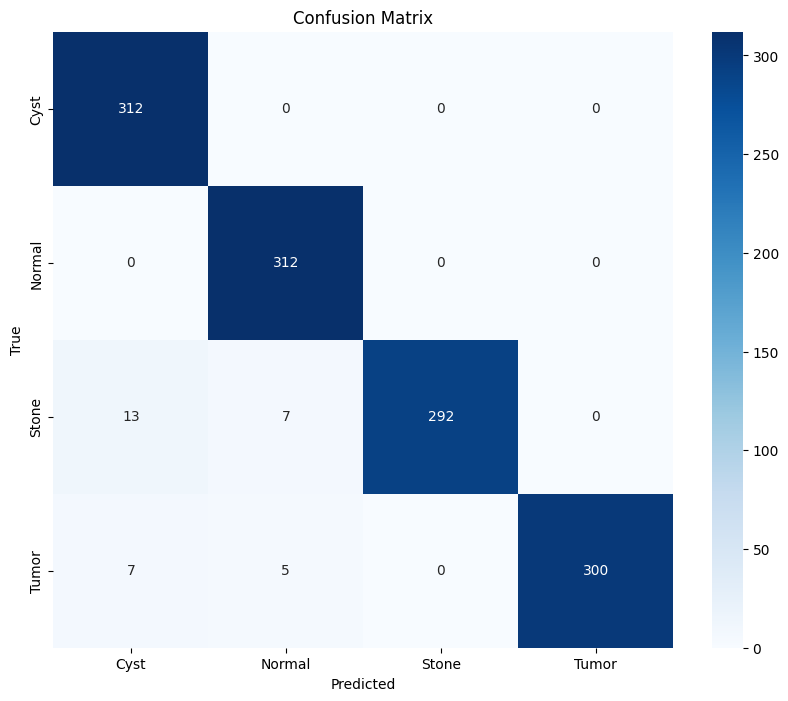

In [50]:
# Use the model to make predictions on the test dataset
predictions = vgg16_model.predict(test_generator, steps=len(test_generator), verbose=1)
# Get the true labels from the test generator
true_labels = test_generator.classes
# Calculate predicted labels from the probability scores
predicted_labels = np.argmax(predictions, axis=1)
# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=test_generator.class_indices)
# Print the classification report
print(report)

# Create a confusion matrix
confusion_mat = confusion_matrix(true_labels, predicted_labels)
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [52]:
# Calculate accuracy
accuracy_stacking = accuracy_score(true_labels, predicted_labels)
print("vgg16 Accuracy :", accuracy_stacking)

vgg16 Accuracy : 0.9743589743589743


# ============= End ====================

# Ensemble

## Load all models


In [6]:
# model 1
with open("model_4classes/vgg_16_model.pkl", "rb") as file:
    vgg16_model = pickle.load(file)
print('vgg16 model loaded \n')
# print(vgg16_model.summary())

# model 2
with open("model_4classes/densenet201_model.pkl", "rb") as file:
    densenet_model = pickle.load(file)

print('densenet201 model loaded \n')
# print(densenet_model.summary())

# model 3
with open("model_4classes/incept_resnetv2_model.pkl", "rb") as file:
    IncepResnetV2_model = pickle.load(file)
print('inceptionresnetv2 model loaded \n')
# print(IncepResnetV2_model.summary())

# model 4
with open("model_4classes/resnet152v2_model.pkl", "rb") as file:
    resnet152v2_model = pickle.load(file)

print('resnet152 model loaded\n')
# print(resnet152v2_model.summary())

2024-06-15 20:40:31.618503: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


vgg16 model loaded 

densenet201 model loaded 

inception resnet v2 model loaded 

resnet152 model loaded



## Best result soft vote

In [30]:
# ensemple using soft vote or average probability

vgg16_predictions = vgg16_model.predict(test_generator)
resnet152v2_predictions = resnet152v2_model.predict(test_generator)
IncepResnetV2_predictions = IncepResnetV2_model.predict(test_generator)
densenet_predictions = densenet_model.predict(test_generator)


# Combine predictions using voting or averaging
ensemble_predictions_boosting = np.mean([vgg16_predictions, resnet152v2_predictions, IncepResnetV2_predictions, densenet_predictions], axis=0)

# Calculate accuracy
true_labels = test_generator.classes
accuracy_boosting = accuracy_score(true_labels, np.argmax(ensemble_predictions_boosting, axis=1))
print("Ensemble Accuracy (Boosting):", accuracy_boosting)

20/20 [==============================] - 82s 4s/step
Ensemble Accuracy (Boosting): 0.9983974358974359


              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       312
      Normal       0.99      1.00      1.00       312
       Stone       1.00      0.99      1.00       312
       Tumor       1.00      1.00      1.00       312

    accuracy                           1.00      1248
   macro avg       1.00      1.00      1.00      1248
weighted avg       1.00      1.00      1.00      1248



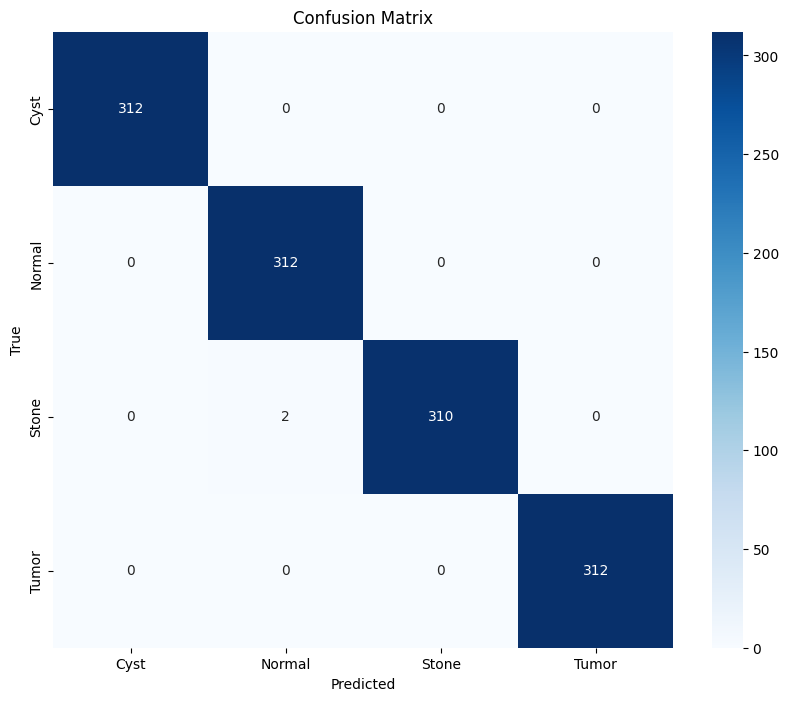

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
# Calculate the confusion matrix
conf_matrix_boost = confusion_matrix(true_labels, np.argmax(ensemble_predictions_boosting, axis=1))
# Generate the classification report
report_boost = classification_report(true_labels, np.argmax(ensemble_predictions_boosting, axis=1), target_names=test_generator.class_indices)
print(report_boost)
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_boost, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()